# Fundamentos de analítica 2 -Aprendizaje Automatico III (clase 1)

## Diego Fernando Agudelo - Daniel Felipe Osorio
## Universidad ICESI
## diegoagudelo30@gmail.com - dfosorio@icesi.edu.co


## **1. Carga de paquetes**

In [92]:
import numpy as np
import pandas as pd # Operaciones con dataframes
from matplotlib import pyplot as plt # gráficos
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error


Este documento presenta una breve introducción a la construcción de objetos de series de tiempo y el cálculo de pronósticos con modelos de suavización.

Para este ejercicio emplearemos la información disponible en el archivo datosEmpleo.xlsx. En ese archivo econtrarán la tasa de desempleo mensual de las 13 principales ciudades en Colombia (TD_13ciudades). El archivo también contiene series mensuales para las 13 principales ciudades de Colombia el número de ocupados en miles de personas (Ocupados), los desocupados (Desocupados) y los inactivos (Inactivos).

## **2. Carga de datos**

Nuestra primera tarea será leer el archivo de Excel. Para eso podemos emplear el paquete Pandas. Carguemos los datos en un objeto que denominaremos data.

In [93]:
data = pd.read_excel("https://raw.githubusercontent.com/profedaniel86/Series_de_Tiempo/refs/heads/main/1.Intro/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


En este caso los datos fueron leídos como un data frame y adicionalmente la columna "mes" fue seleccionada como indice, con el dataframe de esta forma sera más facil trabajar las series de tiempo.

A continuación se gráfica la tasa de desempleo.



(222, 4)


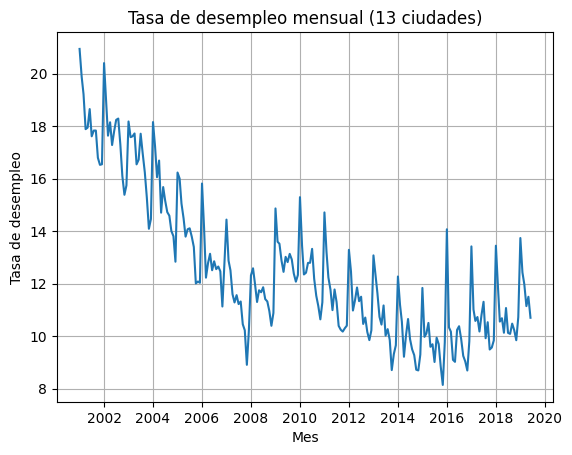

In [94]:
# imprimiendo el tamano del dataframe
print(data.shape)

# Graficando los datos
plt.title("Tasa de desempleo mensual (13 ciudades)")
plt.xlabel("Mes")
plt.ylabel("Tasa de desempleo")
plt.plot(data[["TD_13ciudades"]])
plt.grid()
plt.show()

## **3. Encontrando los componentes de una serie de tiempo**

En algunas ocasiones puede ser útil empezar nuestro análisis descomponiendo la serie de tiempo en sus componentes: **tendencia**, **estacionalidad** y **componente puramente aleatorio**. Una forma de hacer esto es empleando la función seasonal_decompose.

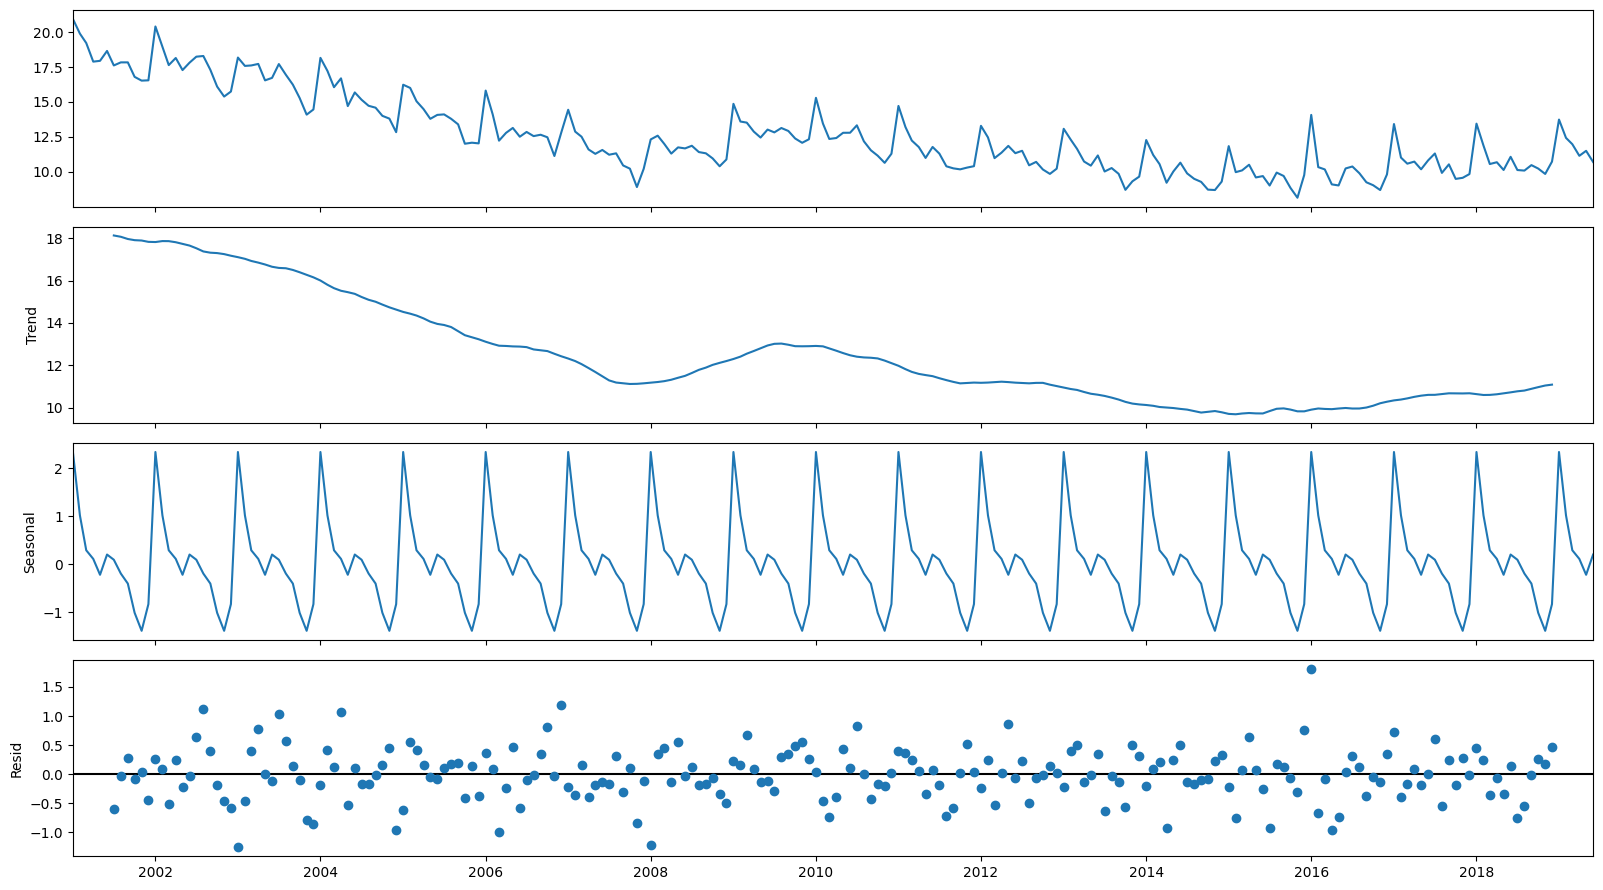

In [95]:
td_componentes = seasonal_decompose(data[["TD_13ciudades"]],model="additive")
fig = td_componentes.plot()
fig.set_size_inches((16, 9))
fig.tight_layout()
plt.show()

Asi se extrae cada elemento de la descomposición de la serie.

In [96]:
td_componentes.seasonal
#td_componentes.trend
#td_componentes.resid

mes
2001-01-01    2.337888
2001-02-01    1.017106
2001-03-01    0.290193
2001-04-01    0.110715
2001-05-01   -0.220208
                ...   
2019-02-01    1.017106
2019-03-01    0.290193
2019-04-01    0.110715
2019-05-01   -0.220208
2019-06-01    0.201178
Name: seasonal, Length: 222, dtype: float64

In [97]:
td_componentes.trend

mes
2001-01-01   NaN
2001-02-01   NaN
2001-03-01   NaN
2001-04-01   NaN
2001-05-01   NaN
              ..
2019-02-01   NaN
2019-03-01   NaN
2019-04-01   NaN
2019-05-01   NaN
2019-06-01   NaN
Name: trend, Length: 222, dtype: float64

In [98]:
td_componentes.resid

mes
2001-01-01   NaN
2001-02-01   NaN
2001-03-01   NaN
2001-04-01   NaN
2001-05-01   NaN
              ..
2019-02-01   NaN
2019-03-01   NaN
2019-04-01   NaN
2019-05-01   NaN
2019-06-01   NaN
Name: resid, Length: 222, dtype: float64

Podemos observar el componente estacional marcado en la serie, una tendencia no lineal de los datos y la parte aleatoria.

Es importante mencionar que esta descomposición se emplea solo como referencia para iniciar el análisis.

Antes de entrar a trabajar con los métodos de suavizamiento, vale la pena anotar que una forma sencilla y rápida para quitar el componente estacional (desestacionalizar) es restarle a la serie el componente estacional encontrado en la descomposición. Es decir,

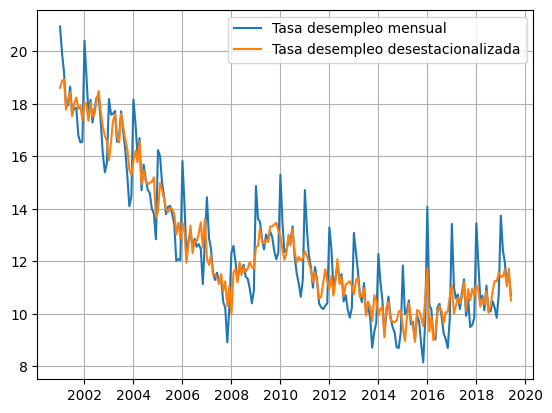

In [99]:
td_desestacionalizada = data["TD_13ciudades"]-td_componentes.seasonal

plt.plot(data[["TD_13ciudades"]],label="Tasa desempleo mensual")
plt.plot(td_desestacionalizada,label="Tasa desempleo desestacionalizada")
plt.legend()
plt.grid()
plt.show()


## **4. Pronosticando metodos de suavización**

Antes de continuar es importante guardar una parte de la muestra para evaluar el comportamiento de los modelos por fuera de muestra (out-of-sample). Guardemos un año de datos.

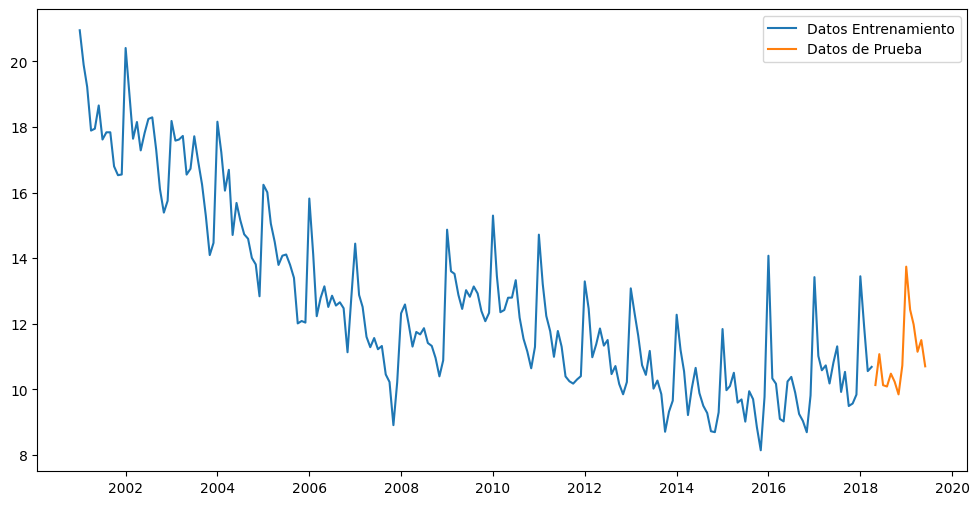

In [100]:
train_len = 208
train_td = data[["TD_13ciudades"]][:train_len]
test_td = data[["TD_13ciudades"]][train_len:]

fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(test_td,label="Datos de Prueba")
plt.legend()
plt.show()

In [101]:
train_td

,TD_13ciudades
mes,
2001-01-01,20.946380
2001-02-01,19.894213
2001-03-01,19.221565
2001-04-01,17.888575
2001-05-01,17.945654
...,...
2017-12-01,9.837395
2018-01-01,13.446245
2018-02-01,11.874973


In [102]:
test_td

,TD_13ciudades
mes,
2018-05-01,10.129211
2018-06-01,11.071347
2018-07-01,10.125100
2018-08-01,10.085244
2018-09-01,10.476567
2018-10-01,10.230811
2018-11-01,9.844539
2018-12-01,10.725865
2019-01-01,13.739328


### **4.1 Promedio movil**

El promedio móvil está dado por:

$$ F_{t + 1}=\frac{Y_{t} + Y_{t-1} + Y_{t-(k-1)} }{ k} $$

El método de los promedios móviles utiliza el promedio de los $k$
valores de datos más recientes en la serie de tiempo como el
pronóstico para el siguiente periodo.

El término móvil indica que, mientras se dispone de una nueva
observación para la serie de tiempo, reemplaza a la observación más
antigua de la ecuación anterior y se calcula un promedio nuevo.
Como resultado, el promedio cambiará, o se moverá, conforme surjan
nuevas observaciones.

$Y_{t}$ = Observación en el período t

$F_{t}$ = Pronóstico en el período t

In [103]:
## Considerando el dato actual
ma_2= train_td.rolling(2,min_periods=2).mean()
ma_3= train_td.rolling(3,min_periods=2).mean()
ma_4= train_td.rolling(4,min_periods=2).mean()
ma_5= train_td.rolling(5,min_periods=2).mean()

In [104]:
## Sin considerar el dato actual
ma_2= train_td.shift().rolling(2,min_periods=2).mean()
ma_3= train_td.shift().rolling(3,min_periods=2).mean()
ma_4= train_td.shift().rolling(4,min_periods=2).mean()
ma_5= train_td.shift().rolling(5,min_periods=2).mean()


In [105]:
def fore_ma(datos,w,h):
  data=datos.copy()
  for x in range(1,h+1):
    ind = data.index[-1]
    value = ind + pd.DateOffset(months=1)
    data.loc[value]= data[-w:].mean()
  return data[-h:]

In [106]:
ma_2_f= fore_ma(train_td,2,14)
ma_3_f= fore_ma(train_td,3,14)
ma_4_f= fore_ma(train_td,4,14)
ma_5_f= fore_ma(train_td,5,14)

In [107]:
test_td

,TD_13ciudades
mes,
2018-05-01,10.129211
2018-06-01,11.071347
2018-07-01,10.125100
2018-08-01,10.085244
2018-09-01,10.476567
2018-10-01,10.230811
2018-11-01,9.844539
2018-12-01,10.725865
2019-01-01,13.739328


In [108]:
ma_2_f

,TD_13ciudades
mes,
2018-05-01,10.618803
2018-06-01,10.651004
2018-07-01,10.634904
2018-08-01,10.642954
2018-09-01,10.638929
2018-10-01,10.640941
2018-11-01,10.639935
2018-12-01,10.640438
2019-01-01,10.640187


In [109]:
rmse_ma_2 = np.sqrt(mean_squared_error(test_td,ma_2_f ))
rmse_ma_3 = np.sqrt(mean_squared_error(test_td,ma_3_f ))
rmse_ma_4 = np.sqrt(mean_squared_error(test_td,ma_4_f ))
rmse_ma_5 = np.sqrt(mean_squared_error(test_td,ma_5_f ))

In [110]:
rmse_ma_5

np.float64(1.079379141938296)

In [111]:
print( rmse_ma_2, rmse_ma_3 ,rmse_ma_4 ,rmse_ma_5)

1.1147962992873541 1.079289141194038 1.0913829514823736 1.079379141938296


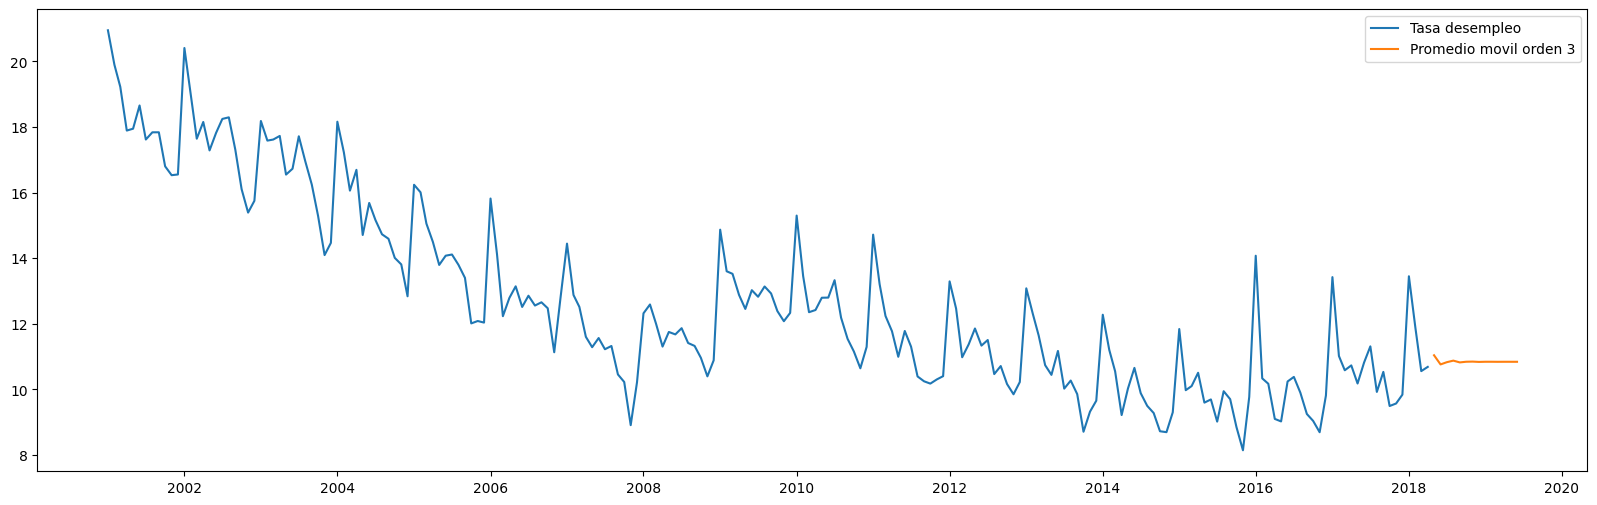

In [112]:
fig = plt.figure(figsize=(20, 6))
plt.plot(train_td,label="Tasa desempleo")
plt.plot(ma_3_f,label="Promedio movil orden 3")
plt.legend()
plt.show()

### **4.2 Suavizacion Exponencial Simple**

In [113]:
# Build model.
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="add")#,trend="add",seasonal="mul" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds = pd.concat([limits, conf_forecast], axis = 1)
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

            Point_forecast  lower_95   upper_95
2018-05-01       10.959788  8.650409  13.269166
2018-06-01       10.959788  8.505554  13.414021
2018-07-01       10.959788  8.368785  13.550791
2018-08-01       10.959788  8.238882  13.680694
2018-09-01       10.959788  8.114904  13.804671
2018-10-01       10.959788  7.996109  13.923467
2018-11-01       10.959788  7.881894  14.037681
2018-12-01       10.959788  7.771769  14.147806
2019-01-01       10.959788  7.665324  14.254252
2019-02-01       10.959788  7.562211  14.357365
2019-03-01       10.959788  7.462137  14.457439
2019-04-01       10.959788  7.364848  14.554728
2019-05-01       10.959788  7.270123  14.649453
2019-06-01       10.959788  7.177770  14.741806


c:\Users\Pipicano\Music\Semester I\Aprendizaje Automatico III\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


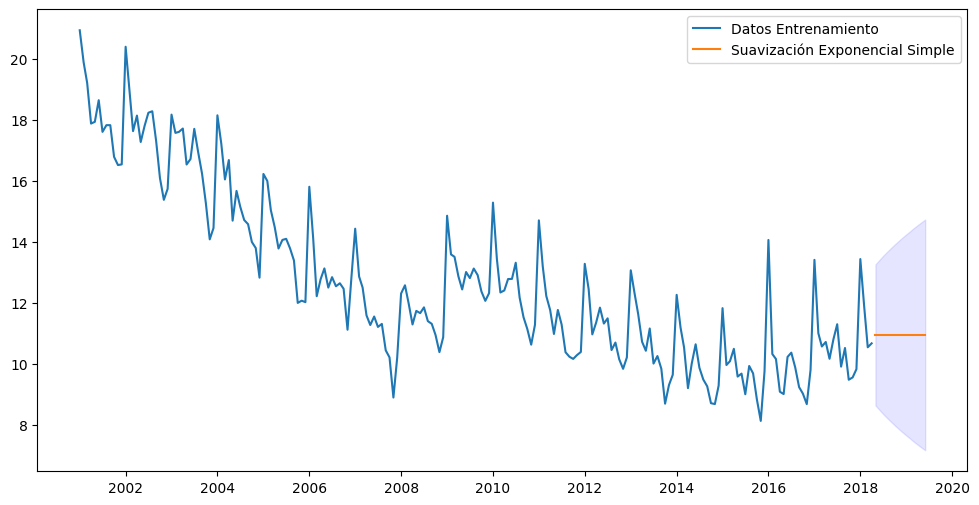

In [114]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds['Point_forecast'],label="Suavización Exponencial Simple")
plt.fill_between(preds.index ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

En esta caso el α estimado es 0.3596639.Y el RMSE en la muestra de evaluación es 1.12

In [115]:
ets_result.alpha

np.float64(0.35969957559668314)

In [116]:
rmse = np.sqrt(mean_squared_error(test_td,point_forecast ))
print(rmse)

1.0532673904186352


### **4.3 Suavizacion Exponencial Lineal (Holt)**

In [117]:
# Build model.
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="mul",trend="mul")#,seasonal="mul" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_holt = pd.concat([limits, conf_forecast], axis = 1)
preds_holt.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_holt)

            Point_forecast  lower_95   upper_95
2018-05-01       10.660587  8.688524  12.782504
2018-06-01       10.632890  8.508990  12.849250
2018-07-01       10.605265  8.458747  12.871738
2018-08-01       10.577711  8.550437  12.775206
2018-09-01       10.550230  8.311427  12.904364
2018-10-01       10.522819  8.345996  12.818041
2018-11-01       10.495480  8.312437  12.672066
2018-12-01       10.468212  8.319783  12.710459
2019-01-01       10.441014  8.213541  12.530313
2019-02-01       10.413888  8.379752  12.836837
2019-03-01       10.386832  8.047578  12.832841
2019-04-01       10.359846  7.972760  12.750698
2019-05-01       10.332930  8.210003  13.095650
2019-06-01       10.306084  8.116706  12.823140


c:\Users\Pipicano\Music\Semester I\Aprendizaje Automatico III\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


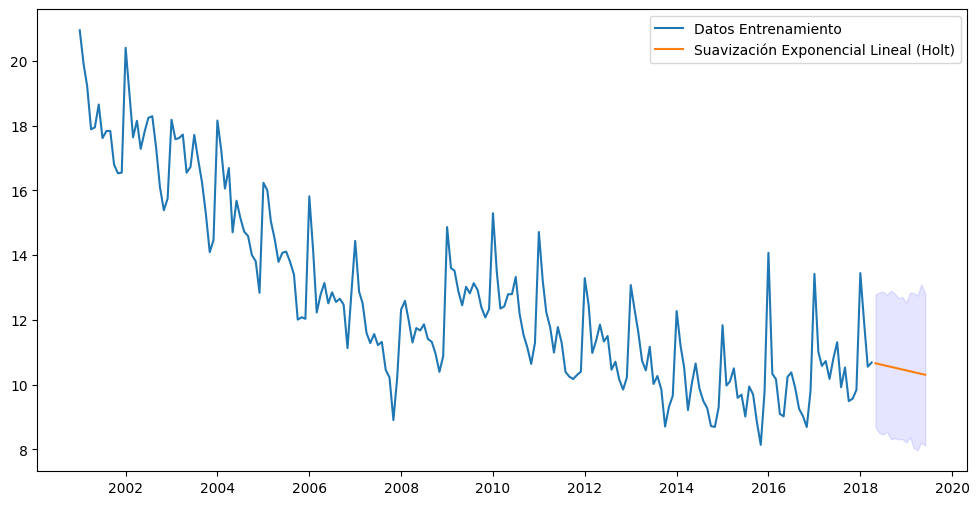

In [118]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_holt['Point_forecast'],label="Suavización Exponencial Lineal (Holt)")
plt.fill_between(preds_holt.index ,preds_holt['lower_95'], preds_holt['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

En esta caso el α estimado es 0.17153975893378887 y el β estimado es 1.7153975893378887$^{-5}$. Y el RMSE en la muestra de evaluación es 1.2780044501304348.

In [119]:
print(ets_result.alpha,ets_result.beta)

0.17153909365393913 1.7153909365393913e-05


In [120]:
rmse_holt = np.sqrt(mean_squared_error(test_td,preds_holt['Point_forecast']))
print(rmse_holt)

1.228145801463044


## **4.3 Suavizacion Exponencial Lineal de Winters (Holt-Winters)**

In [121]:
# Build model
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="add",trend="add",seasonal="add" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_hw_add = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_add.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_add)

            Point_forecast   lower_95   upper_95
2018-05-01       10.297371   9.251560  11.343183
2018-06-01       10.674325   9.532337  11.816313
2018-07-01       10.565100   9.334412  11.795788
2018-08-01       10.226589   8.913162  11.540017
2018-09-01        9.946370   8.555100  11.337640
2018-10-01        9.282632   7.817635  10.747628
2018-11-01        8.875136   7.339935  10.410336
2018-12-01        9.376551   7.774206  10.978895
2019-01-01       12.534208  10.867410  14.201006
2019-02-01       11.193066   9.464203  12.921928
2019-03-01       10.434228   8.645441  12.223015
2019-04-01       10.158460   8.311680  12.005240
2019-05-01        9.827778   7.924747  11.730809
2019-06-01       10.204732   8.247068  12.162395


c:\Users\Pipicano\Music\Semester I\Aprendizaje Automatico III\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


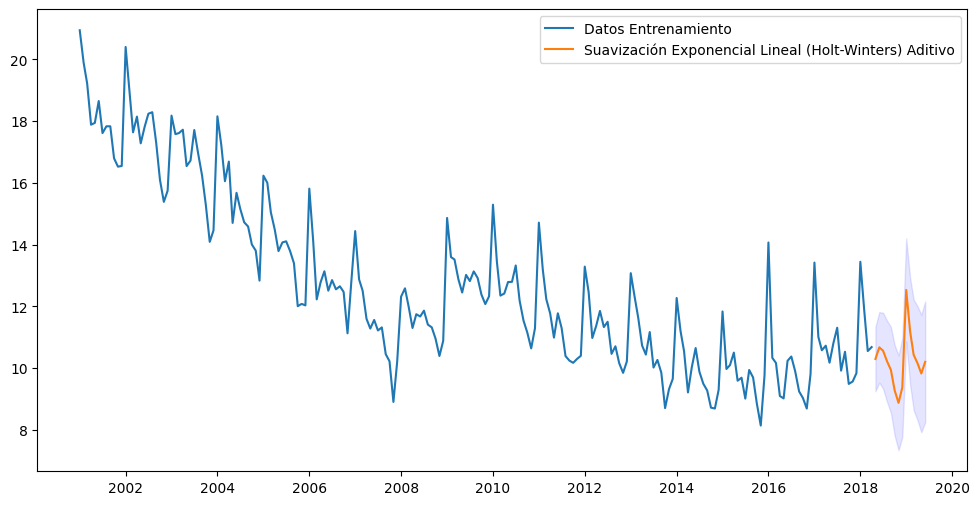

In [122]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_hw_add['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) Aditivo")
plt.fill_between(preds_hw_add.index ,preds_hw_add['lower_95'], preds_hw_add['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [123]:
print(ets_result.alpha,ets_result.beta,ets_result.gamma)

0.43857184633310375 4.385718463331038e-05 5.6142815366689624e-05


In [124]:
rmse_hw_add = np.sqrt(mean_squared_error(test_td,preds_hw_add['Point_forecast']))
print(rmse_hw_add)

0.9893610351254504


In [125]:
# Build model.
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="add",trend=None,seasonal="mul" , )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_hw_mul = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_mul)

            Point_forecast   lower_95   upper_95
2018-05-01       10.433036   9.320981  11.543064
2018-06-01       10.981856   9.730139  12.221637
2018-07-01       10.779516   9.406971  12.118724
2018-08-01       10.380956   8.979270  11.724559
2018-09-01       10.300534   8.775789  11.858736
2018-10-01        9.708898   8.215742  11.211841
2018-11-01        9.565507   8.111230  11.172175
2018-12-01       10.265134   8.613656  12.109226
2019-01-01       13.399531  11.276627  15.545010
2019-02-01       11.447407   9.515674  13.480324
2019-03-01       10.843306   8.953209  12.927410
2019-04-01       10.618172   8.631568  12.735550
2019-05-01       10.433036   8.552144  12.562503
2019-06-01       10.981856   8.883814  13.208722


c:\Users\Pipicano\Music\Semester I\Aprendizaje Automatico III\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


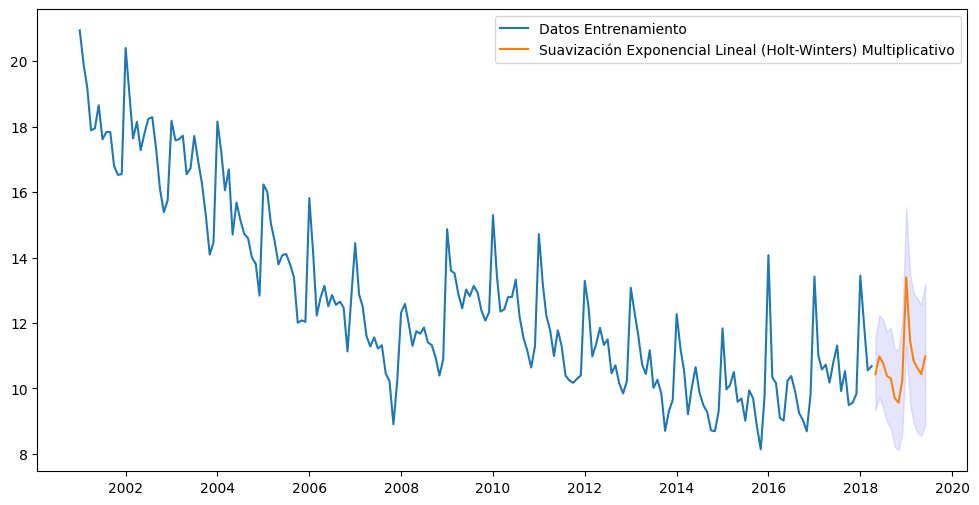

In [126]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_hw_mul['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) Multiplicativo")
plt.fill_between(preds_hw_mul.index ,preds_hw_mul['lower_95'], preds_hw_mul['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [127]:
print(ets_result.alpha,ets_result.gamma)

0.4314982974685176 0.1609708946436222


In [128]:
rmse_hw_mul = np.sqrt(mean_squared_error(test_td,preds_hw_mul['Point_forecast']))
print(rmse_hw_mul)

0.601249106131057


## **5. Ejercicio en Clase**

Empleando la información del número de ocupados en miles de personas (Ocupados) para las 13 principales ciudades, encuentre el mejor pronóstico para los próximos 6 meses. Escriba un breve informe de máximo una página de texto que explique cómo llega a sus proyeccciones y presente las proyecciones. Aclare en el texto cuáles serían las limitaciones de sus pronósticos.

In [ ]:
# Probar diferentes modelos de suavización exponencial


simple_forecast = ets_simple_result.forecast(6)

# 2. Método de Holt (con tendencia)
ets_holt = ETSModel(endog=train_ocupados["Ocupados"], error="add", trend="add")
ets_holt_result = ets_holt.fit()
holt_forecast = ets_holt_result.forecast(6)

# 3. Método de Holt-Winters (con tendencia y estacionalidad)
ets_hw = ETSModel(endog=train_ocupados["Ocupados"], error="add", trend="add", seasonal="add")
ets_hw_result = ets_hw.fit()
hw_forecast = ets_hw_result.forecast(6)

# Calcular RMSE para cada modelo usando los datos de prueba
rmse_simple = np.sqrt(mean_squared_error(test_ocupados[:6], simple_forecast))
rmse_holt = np.sqrt(mean_squared_error(test_ocupados[:6], holt_forecast))
rmse_hw = np.sqrt(mean_squared_error(test_ocupados[:6], hw_forecast))

print("RMSE Suavización Simple:", rmse_simple)
print("RMSE Holt:", rmse_holt)
print("RMSE Holt-Winters:", rmse_hw)

# Graficar los pronósticos
plt.figure(figsize=(12, 6))
plt.plot(train_ocupados.index, train_ocupados["Ocupados"], label="Datos históricos")
plt.plot(test_ocupados.index[:6], test_ocupados["Ocupados"][:6], label="Datos reales")
plt.plot(simple_forecast.index, simple_forecast, '--', label="Pronóstico Simple")
plt.plot(holt_forecast.index, holt_forecast, '--', label="Pronóstico Holt")
plt.plot(hw_forecast.index, hw_forecast, '--', label="Pronóstico Holt-Winters")
plt.title("Comparación de Pronósticos")
plt.legend()
plt.grid(True)
plt.show()

# Usar el mejor modelo para hacer el pronóstico final de 6 meses
mejor_modelo = ets_hw  # Se ajustará según los resultados del RMSE
mejor_resultado = ets_hw_result
datos_completos = data[["Ocupados"]]
modelo_final = ETSModel(endog=datos_completos["Ocupados"], error="add", trend="add", seasonal="add")
resultado_final = modelo_final.fit()
pronostico_final = resultado_final.forecast(6)

# Mostrar pronósticos finales
print("\nPronósticos para los próximos 6 meses:")
print(pronostico_final)